In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from src.load_data_BCICIV import load_all_subjects
from src.train_EEGNet import train_model_cv, evaluate_model
import torch
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)


# DATA LOAD

In [2]:
data_path = '../datasets/BCICIV_2a_gdf'

data_22 = load_all_subjects(data_path, channels_to_use='all')
data_22_multiband = load_all_subjects(data_path, use_multiband=True, bands=[(8, 12), (13, 30)], channels_to_use='all')
data_11 = load_all_subjects(data_path)
data_11_multiband = load_all_subjects(data_path, use_multiband=True, bands=[(8, 12), (13, 30)])

/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A01T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A02T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A08T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A09T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-l

In [3]:
test_subjects = np.random.choice(np.unique(data_22['subject_ids']), size=2, replace=False)
print(f"Selected test subjects: {test_subjects}")

all_subjects = np.unique(data_22['subject_ids'])
train_subjects = all_subjects[~np.isin(all_subjects, test_subjects)]
train_mask = np.isin(data_22['subject_ids'], train_subjects)
subjects_train = data_22['subject_ids'][train_mask]

X_train_22 = data_22['X'][~np.isin(data_22['subject_ids'], test_subjects)]
y_train_22 = data_22['y'][~np.isin(data_22['subject_ids'], test_subjects)]
X_test_22 = data_22['X'][np.isin(data_22['subject_ids'], test_subjects)]
y_test_22 = data_22['y'][np.isin(data_22['subject_ids'], test_subjects)]

X_train_22_multiband = data_22_multiband['X'][~np.isin(data_22_multiband['subject_ids'], test_subjects)]
y_train_22_multiband = data_22_multiband['y'][~np.isin(data_22_multiband['subject_ids'], test_subjects)]
X_test_22_multiband = data_22_multiband['X'][np.isin(data_22_multiband['subject_ids'], test_subjects)]
y_test_22_multiband = data_22_multiband['y'][np.isin(data_22_multiband['subject_ids'], test_subjects)]

X_train_11 = data_11['X'][~np.isin(data_11['subject_ids'], test_subjects)]
y_train_11 = data_11['y'][~np.isin(data_11['subject_ids'], test_subjects)]
X_test_11 = data_11['X'][np.isin(data_11['subject_ids'], test_subjects)]
y_test_11 = data_11['y'][np.isin(data_11['subject_ids'], test_subjects)]

X_train_11_multiband = data_11_multiband['X'][~np.isin(data_11_multiband['subject_ids'], test_subjects)]
y_train_11_multiband = data_11_multiband['y'][~np.isin(data_11_multiband['subject_ids'], test_subjects)]
X_test_11_multiband = data_11_multiband['X'][np.isin(data_11_multiband['subject_ids'], test_subjects)]
y_test_11_multiband = data_11_multiband['y'][np.isin(data_11_multiband['subject_ids'], test_subjects)]

Selected test subjects: ['A08' 'A02']


In [4]:
models = {
    'model': [],
    'accuracies': [],
    'name': []
}

# Tests with 22 channels

## 22 channels (raw + normalization)

In [5]:
model, test_subject_accuracies = train_model_cv(X_train_22, y_train_22, subjects_train, transforms=[], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('raw_22')

Early stopping.
Fold 1: Test Accuracy: 0.7203


Early stopping.
Fold 2: Test Accuracy: 0.7153


Early stopping.
Fold 3: Test Accuracy: 0.6853


Early stopping.
Fold 4: Test Accuracy: 0.7014


Early stopping.
Fold 5: Test Accuracy: 0.5764


Early stopping.
Fold 6: Test Accuracy: 0.6806


Early stopping.
Fold 7: Test Accuracy: 0.5486
Mean Subject Accuracy: 0.6611
Standard Deviation: 0.0642


Early stopping.


In [6]:
test_acc = evaluate_model(model, X_test_22, y_test_22, transforms=[])
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.5938


## 22 channels + laplacian filter on C3 and C4

In [7]:
model, test_subject_accuracies = train_model_cv(X_train_22, y_train_22, subjects_train, transforms=['laplacian'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22')

Early stopping.
Fold 1: Test Accuracy: 0.7552


Early stopping.
Fold 2: Test Accuracy: 0.7569


Early stopping.
Fold 3: Test Accuracy: 0.7133


Early stopping.
Fold 4: Test Accuracy: 0.6806


Early stopping.
Fold 5: Test Accuracy: 0.6597


Early stopping.
Fold 6: Test Accuracy: 0.6944


Early stopping.
Fold 7: Test Accuracy: 0.5417
Mean Subject Accuracy: 0.6860
Standard Deviation: 0.0678


Early stopping.


In [8]:
test_acc = evaluate_model(model, X_test_22, y_test_22, transforms=['laplacian'])
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.6007


## 22 channels - only mu band

In [9]:
model, test_subject_accuracies = train_model_cv(X_train_22_multiband, y_train_22_multiband, subjects_train, transforms=['laplacian', 'mu_band'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('mu_22')

Early stopping.
Fold 1: Test Accuracy: 0.6713


Early stopping.
Fold 2: Test Accuracy: 0.7222


Early stopping.
Fold 3: Test Accuracy: 0.6643


Early stopping.
Fold 4: Test Accuracy: 0.6667


Early stopping.
Fold 5: Test Accuracy: 0.6319


Early stopping.
Fold 6: Test Accuracy: 0.6319


Early stopping.
Fold 7: Test Accuracy: 0.5486
Mean Subject Accuracy: 0.6482
Standard Deviation: 0.0494


Early stopping.


In [10]:
test_acc = evaluate_model(model, X_test_22_multiband, y_test_22_multiband, transforms=['laplacian', 'mu_band'])
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.6215


## 22 channels - mu + beta band

In [11]:
model, test_subject_accuracies = train_model_cv(X_train_22_multiband, y_train_22_multiband, subjects_train, transforms=['laplacian', 'multiband'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('multiband_22')

Early stopping.
Fold 1: Test Accuracy: 0.7552


Early stopping.
Fold 2: Test Accuracy: 0.6944


Early stopping.
Fold 3: Test Accuracy: 0.6923


Early stopping.
Fold 4: Test Accuracy: 0.6528


Early stopping.
Fold 5: Test Accuracy: 0.6597


Early stopping.
Fold 6: Test Accuracy: 0.6458


Early stopping.
Fold 7: Test Accuracy: 0.5486
Mean Subject Accuracy: 0.6641
Standard Deviation: 0.0584


Early stopping.


In [12]:
test_acc = evaluate_model(model, X_test_22_multiband, y_test_22_multiband, transforms=['laplacian', 'multiband'])
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.5903


# Tests with 11 channels

## 11 channels (raw + normalization)

In [14]:
model, test_subject_accuracies = train_model_cv(X_train_11, y_train_11, subjects_train, transforms=[], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('raw_11')

Early stopping.
Fold 1: Test Accuracy: 0.7483


Early stopping.
Fold 2: Test Accuracy: 0.7222


Early stopping.
Fold 3: Test Accuracy: 0.6573


Early stopping.
Fold 4: Test Accuracy: 0.6875


Early stopping.
Fold 5: Test Accuracy: 0.6458


Early stopping.
Fold 6: Test Accuracy: 0.6944


Early stopping.
Fold 7: Test Accuracy: 0.5139
Mean Subject Accuracy: 0.6671
Standard Deviation: 0.0705


Early stopping.


In [16]:
test_acc = evaluate_model(model, X_test_11, y_test_11, transforms=[])
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.6042


## 11 channels + laplacian filter on C3 and C4

In [17]:
model, test_subject_accuracies = train_model_cv(X_train_11, y_train_11, subjects_train, transforms=['laplacian'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_11')

Early stopping.
Fold 1: Test Accuracy: 0.7413


Early stopping.
Fold 2: Test Accuracy: 0.8403


Early stopping.
Fold 3: Test Accuracy: 0.6294


Early stopping.
Fold 4: Test Accuracy: 0.7500


Early stopping.
Fold 5: Test Accuracy: 0.6111


Early stopping.
Fold 6: Test Accuracy: 0.7917


Early stopping.
Fold 7: Test Accuracy: 0.5972
Mean Subject Accuracy: 0.7087
Standard Deviation: 0.0888


Early stopping.


In [18]:
test_acc = evaluate_model(model, X_test_11, y_test_11, transforms=['laplacian'])
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.6007


## 11 channels - only mu band

In [19]:
model, test_subject_accuracies = train_model_cv(X_train_11_multiband, y_train_11_multiband, subjects_train, transforms=['laplacian', 'mu_band'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('mu_11')

Early stopping.
Fold 1: Test Accuracy: 0.6993


Early stopping.
Fold 2: Test Accuracy: 0.8125


Early stopping.
Fold 3: Test Accuracy: 0.6084


Early stopping.
Fold 4: Test Accuracy: 0.6736


Early stopping.
Fold 5: Test Accuracy: 0.5764


Early stopping.
Fold 6: Test Accuracy: 0.7014


Early stopping.
Fold 7: Test Accuracy: 0.5486
Mean Subject Accuracy: 0.6600
Standard Deviation: 0.0835


Early stopping.


In [20]:
test_acc = evaluate_model(model, X_test_11_multiband, y_test_11_multiband, transforms=['laplacian', 'mu_band'])
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.5972


## 11 channels - mu + beta band

In [21]:
model, test_subject_accuracies = train_model_cv(X_train_11_multiband, y_train_11_multiband, subjects_train, transforms=['laplacian', 'multiband'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('multiband_11')

Early stopping.
Fold 1: Test Accuracy: 0.7762


Early stopping.
Fold 2: Test Accuracy: 0.8403


Early stopping.
Fold 3: Test Accuracy: 0.6503


Early stopping.
Fold 4: Test Accuracy: 0.7153


Early stopping.
Fold 5: Test Accuracy: 0.6458


Early stopping.
Fold 6: Test Accuracy: 0.7639


Early stopping.
Fold 7: Test Accuracy: 0.5556
Mean Subject Accuracy: 0.7068
Standard Deviation: 0.0892


Early stopping.


In [22]:
test_acc = evaluate_model(model, X_test_11_multiband, y_test_11_multiband, transforms=['laplacian', 'multiband'])
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.5938


# Visualization

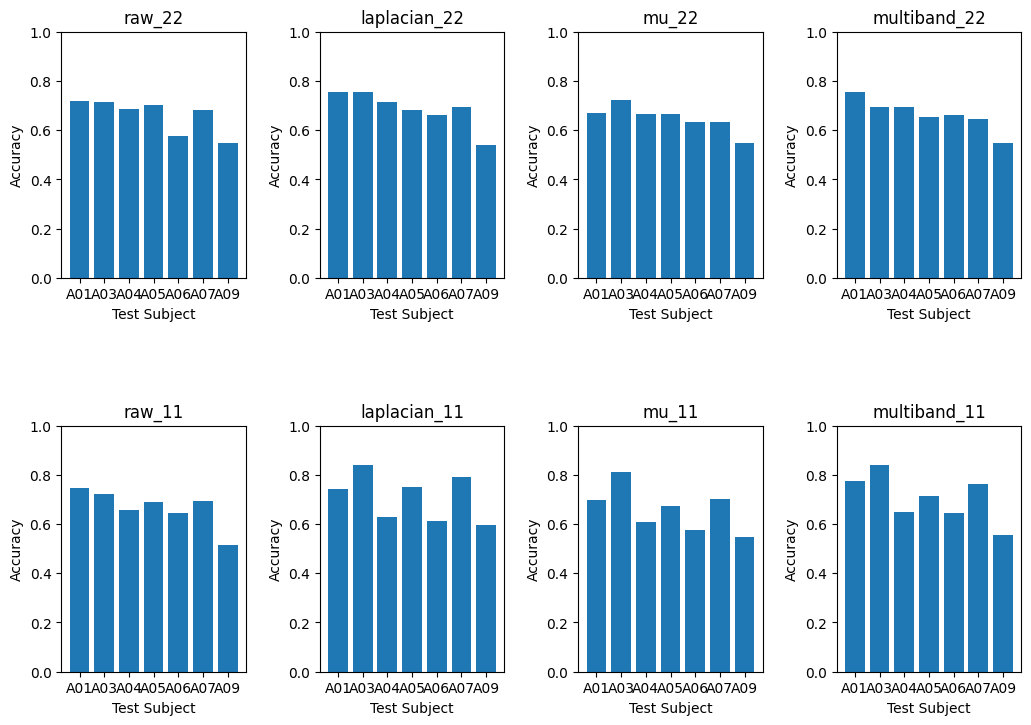

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(12, 8))

for i, (name, accuracies) in enumerate(zip(models['name'], models['accuracies'])):
    ax = axes[i // 4, i % 4]
    ax.bar(np.unique(subjects_train), accuracies)
    ax.set_title(name)
    ax.set_xlabel('Test Subject')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.6)